In [1]:
import sleap
import sys
import cmath
import json
import os

sys.path.append('..')
from python.polygon_based_correction import *
from eval.eval import *
from python.dataset_conversion import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [17]:
training_json_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/models/250221_022817.centroid.n=4149/training_config.json'
# training_json_path = '/home/mingxiao/Desktop/jellyfish/label/models/250214_122024.single_instance.n=1653/training_config.json'
training_config = json.load(open(training_json_path))

In [19]:
val_indices = np.array(training_config['data']['labels']['validation_inds'])
train_indices = np.array(training_config['data']['labels']['training_inds'])
print(val_indices.shape)
print(train_indices.shape)

(415,)
(3734,)


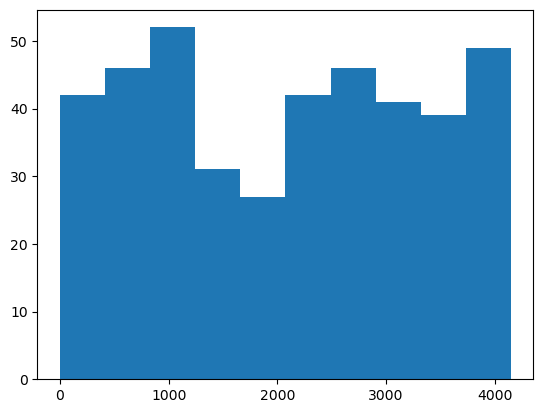

In [20]:
plt.hist(val_indices);

In [2]:
single_animal_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/animal_1_labels.v002.slp'
single_animal_dataset = sleap.load_file(single_animal_dataset_path)
print(single_animal_dataset)
multi_animal_dataset = single2multi(single_animal_dataset)
print(multi_animal_dataset)

Labels(labeled_frames=8089, videos=1, skeletons=1, tracks=0)
Tentacle count: 17
Average mouth location: [86.18999969 79.86647831]
Labels(labeled_frames=1653, videos=1, skeletons=1, tracks=17)


In [4]:
single_animal_dataset.skeleton

Skeleton(name='Skeleton-1', description='None', nodes=['Mouth', 'TB1', 'TB2', 'TB3', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'TB12', 'TB13', 'TB14', 'TB15', 'TB16', 'TB17'], edges=[('Mouth', 'TB1'), ('Mouth', 'TB2'), ('Mouth', 'TB3'), ('Mouth', 'TB4'), ('Mouth', 'TB5'), ('Mouth', 'TB6'), ('Mouth', 'TB7'), ('Mouth', 'TB8'), ('Mouth', 'TB9'), ('Mouth', 'TB10'), ('Mouth', 'TB11'), ('Mouth', 'TB12'), ('Mouth', 'TB13'), ('Mouth', 'TB14'), ('Mouth', 'TB15'), ('Mouth', 'TB16'), ('Mouth', 'TB17')], symmetries=[])

In [3]:
src_multi_animal_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
src_multi_animal_dataset = sleap.load_file(src_multi_animal_dataset_path)
print(src_multi_animal_dataset)
src_single_animal_dataset = multi2single(src_multi_animal_dataset)
print(src_single_animal_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
Tentacle count: 17
Labels(labeled_frames=5202, videos=1, skeletons=1, tracks=0)


In [5]:
src_single_animal_dataset.skeleton

Skeleton(name='jellyfish', description='None', nodes=['Mouth', 'TB1', 'TB2', 'TB3', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'TB12', 'TB13', 'TB14', 'TB15', 'TB16', 'TB17'], edges=[('Mouth', 'TB1'), ('Mouth', 'TB2'), ('Mouth', 'TB3'), ('Mouth', 'TB4'), ('Mouth', 'TB5'), ('Mouth', 'TB6'), ('Mouth', 'TB7'), ('Mouth', 'TB8'), ('Mouth', 'TB9'), ('Mouth', 'TB10'), ('Mouth', 'TB11'), ('Mouth', 'TB12'), ('Mouth', 'TB13'), ('Mouth', 'TB14'), ('Mouth', 'TB15'), ('Mouth', 'TB16'), ('Mouth', 'TB17')], symmetries=[])

In [9]:
multi_v11_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/multifish_animal_1_v11.slp'
multi_v11_dataset = sleap.load_file(multi_v11_dataset_path)
print(multi_v11_dataset)

Labels(labeled_frames=4149, videos=1, skeletons=1, tracks=17)


In [17]:
def multi2single(multi_animal_dataset: sleap.Labels, 
                 mouth_location: Sequence[float]=(86.19, 79.87),
                 copy_suggestions: bool=True, 
                 exclude_missing_frames: bool=True,
                 save_path: str=None) -> sleap.Labels:
    
    assert multi_animal_dataset.tracks, 'Tracks are not assigned'
    single_animal_dataset = copy(multi_animal_dataset)
    tb_cnt = len(multi_animal_dataset.tracks)
    print(f'Tentacle count: {tb_cnt}')
    
    new_skeleton = sleap.Skeleton(name=f'jellyfish')
    new_skeleton.add_node(f'Mouth')
    for i in range(tb_cnt):
        new_skeleton.add_node(f'TB{i+1}')
        new_skeleton.add_edge(f'Mouth', f'TB{i+1}')
    single_animal_dataset.skeletons = [new_skeleton]
    
    new_labeled_frames = []
    for lf in multi_animal_dataset.labeled_frames:
        # generate new instances 
        instances = [inst for inst in lf.instances \
            if not isinstance(inst, sleap.PredictedInstance) and isinstance(inst, sleap.Instance) and len(inst.points) > 0]
        if exclude_missing_frames and len(instances) < tb_cnt:
            continue
        point_dict = {f'Mouth': sleap.instance.Point(x=mouth_location[0], y=mouth_location[1])}
        curr_tb_cnt = 0
        
        for inst in instances:
            try:
                old_point = inst.points[0]
                tb_idx = int(inst.track.name[6:]) + 1
                point_dict[f'TB{tb_idx}'] = sleap.instance.Point(x=old_point.x, y=old_point.y)
                curr_tb_cnt += 1
            except Exception as e:
                print(inst)
                raise e
            
        jellyfish_inst = sleap.Instance(skeleton=new_skeleton, points=point_dict, frame=lf)
            
        if curr_tb_cnt != tb_cnt:
            print(f'TB count mismatch at frame {lf.frame_idx}: {curr_tb_cnt} != {tb_cnt}')
            
        new_lf = sleap.LabeledFrame(video=single_animal_dataset.video, frame_idx=lf.frame_idx, instances=[jellyfish_inst])
        new_labeled_frames.append(new_lf)
    
    single_animal_dataset.labeled_frames = new_labeled_frames
    single_animal_dataset.tracks = []
    
    if copy_suggestions:
        copy_suggestions_func(multi_animal_dataset, single_animal_dataset)
    
    if save_path is not None:
        parent_dir = os.path.dirname(save_path)
        if not os.path.exists(parent_dir):
            os.makedirs(parent_dir)
        single_animal_dataset.save(save_path)
    
    return single_animal_dataset

In [18]:
single_v10_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/animal_1_labels_v11.slp'
single_v10_dataset = multi2single(multi_v11_dataset, save_path=single_v10_dataset_path)
print(single_v10_dataset)

Tentacle count: 17
Labels(labeled_frames=4144, videos=1, skeletons=1, tracks=0)
